<a href="https://colab.research.google.com/github/Sachindara360/rag-distractor-robustness/blob/main/rag_distractor_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import pipeline

dataset = load_dataset("rajpurkar/squad", split="validation[:100]")

generator = pipeline("text-generation", model="google/flan-t5-base", device=-1)
results = []

for idx, item in enumerate(dataset):
    question = item["question"]
    gold_context = item["context"]
    ground_truths = item["answers"]["text"]

    distractor_idx = (idx + 10) % len(dataset)
    distractor_context = dataset[distractor_idx]["context"]

    prompt_c1 = f"context: {gold_context} question: {question}"

    prompt_c2 = f"context: {distractor_context} \n {gold_context} question: {question}"

    pred_c1 = generator(prompt_c1, max_new_tokens=30)[0]["generated_text"]
    pred_c2 = generator(prompt_c2, max_new_tokens=30)[0]["generated_text"]

    # Check simple exact match (EM)
    em_c1 = int(any(gt.lower() in pred_c1.lower() for gt in ground_truths))
    em_c2 = int(any(gt.lower() in pred_c2.lower() for gt in ground_truths))

    results.append({"id": idx, "em_c1": em_c1, "em_c2": em_c2})

df = pd.DataFrame(results)
print("Condition 1 (Clean Context) Accuracy:", df["em_c1"].mean() * 100)
print("Condition 2 (Noisy Context) Accuracy:", df["em_c2"].mean() * 100)
df.to_csv("experiment_results.csv", index=False)

README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'AXK1ForCausalLM', 'AXK2ForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CohereCompassForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV32ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM',

Condition 1 (Clean Context) Accuracy: 100.0
Condition 2 (Noisy Context) Accuracy: 100.0


In [2]:
import re
import string
import logging
from collections import Counter
import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm


logging.getLogger("transformers").setLevel(logging.ERROR)

def normalize_text(s):
    """Lower text and strip punctuation, articles, and extra whitespace."""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    return white_space_fix(remove_articles(remove_punc(s.lower())))

def compute_exact_match(prediction, ground_truth):
    return int(normalize_text(prediction) == normalize_text(ground_truth))

def compute_f1(prediction, ground_truth):
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)
    if num_same == 0:
        return 0.0
    precision = 1.0 * num_same / len(pred_tokens)
    recall = 1.0 * num_same / len(gt_tokens)
    return (2 * precision * recall) / (precision + recall)

def score_prediction(prediction, ground_truths):
    em = max(compute_exact_match(prediction, gt) for gt in ground_truths)
    f1 = max(compute_f1(prediction, gt) for gt in ground_truths)
    return em, f1

dataset = load_dataset("rajpurkar/squad", split="validation[:100]")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
model.eval()

model.generation_config.max_length = None

def generate_answer(prompt_text):
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            generation_config=model.generation_config
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

records = []
for idx in tqdm(range(len(dataset)), desc="Evaluating RAG conditions"):
    item = dataset[idx]
    q = item["question"]
    gold = item["context"]
    gts = item["answers"]["text"]

    dist_context = dataset[(idx + 25) % len(dataset)]["context"]

    # Condition 1: Clean Non-Parametric Context
    prompt_clean = f"Read the context and answer the question.\n\nContext: {gold}\n\nQuestion: {q}\nAnswer:"

    # Condition 2: Noisy Non-Parametric Context (Distractor + Gold)
    prompt_noisy = f"Read the context and answer the question.\n\nContext: {dist_context}\n\n{gold}\n\nQuestion: {q}\nAnswer:"

    pred_c = generate_answer(prompt_clean)
    pred_n = generate_answer(prompt_noisy)

    em_c, f1_c = score_prediction(pred_c, gts)
    em_n, f1_n = score_prediction(pred_n, gts)

    records.append({
        "question": q,
        "prediction_clean": pred_c,
        "prediction_noisy": pred_n,
        "gold_answers": gts,
        "em_clean": em_c,
        "f1_clean": f1_c,
        "em_noisy": em_n,
        "f1_noisy": f1_n
    })

df = pd.DataFrame(records)

print("\n" + "="*50)
print("EMPIRICAL RESULTS FOR POSTER TABLE:")
print("="*50)
print(f"Condition 1 (Clean Context) -> Exact Match: {df['em_clean'].mean()*100:.2f}% | F1: {df['f1_clean'].mean()*100:.2f}%")
print(f"Condition 2 (Noisy Context) -> Exact Match: {df['em_noisy'].mean()*100:.2f}% | F1: {df['f1_noisy'].mean()*100:.2f}%")
print("="*50)

df.to_csv("squad_rag_results.csv", index=False)
print("Saved experiment results to squad_rag_results.csv")

README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Evaluating RAG conditions:   0%|          | 0/100 [00:00<?, ?it/s]


EMPIRICAL RESULTS FOR POSTER TABLE:
Condition 1 (Clean Context) -> Exact Match: 45.00% | F1: 45.00%
Condition 2 (Noisy Context) -> Exact Match: 40.00% | F1: 40.00%
Saved experiment results to squad_rag_results.csv


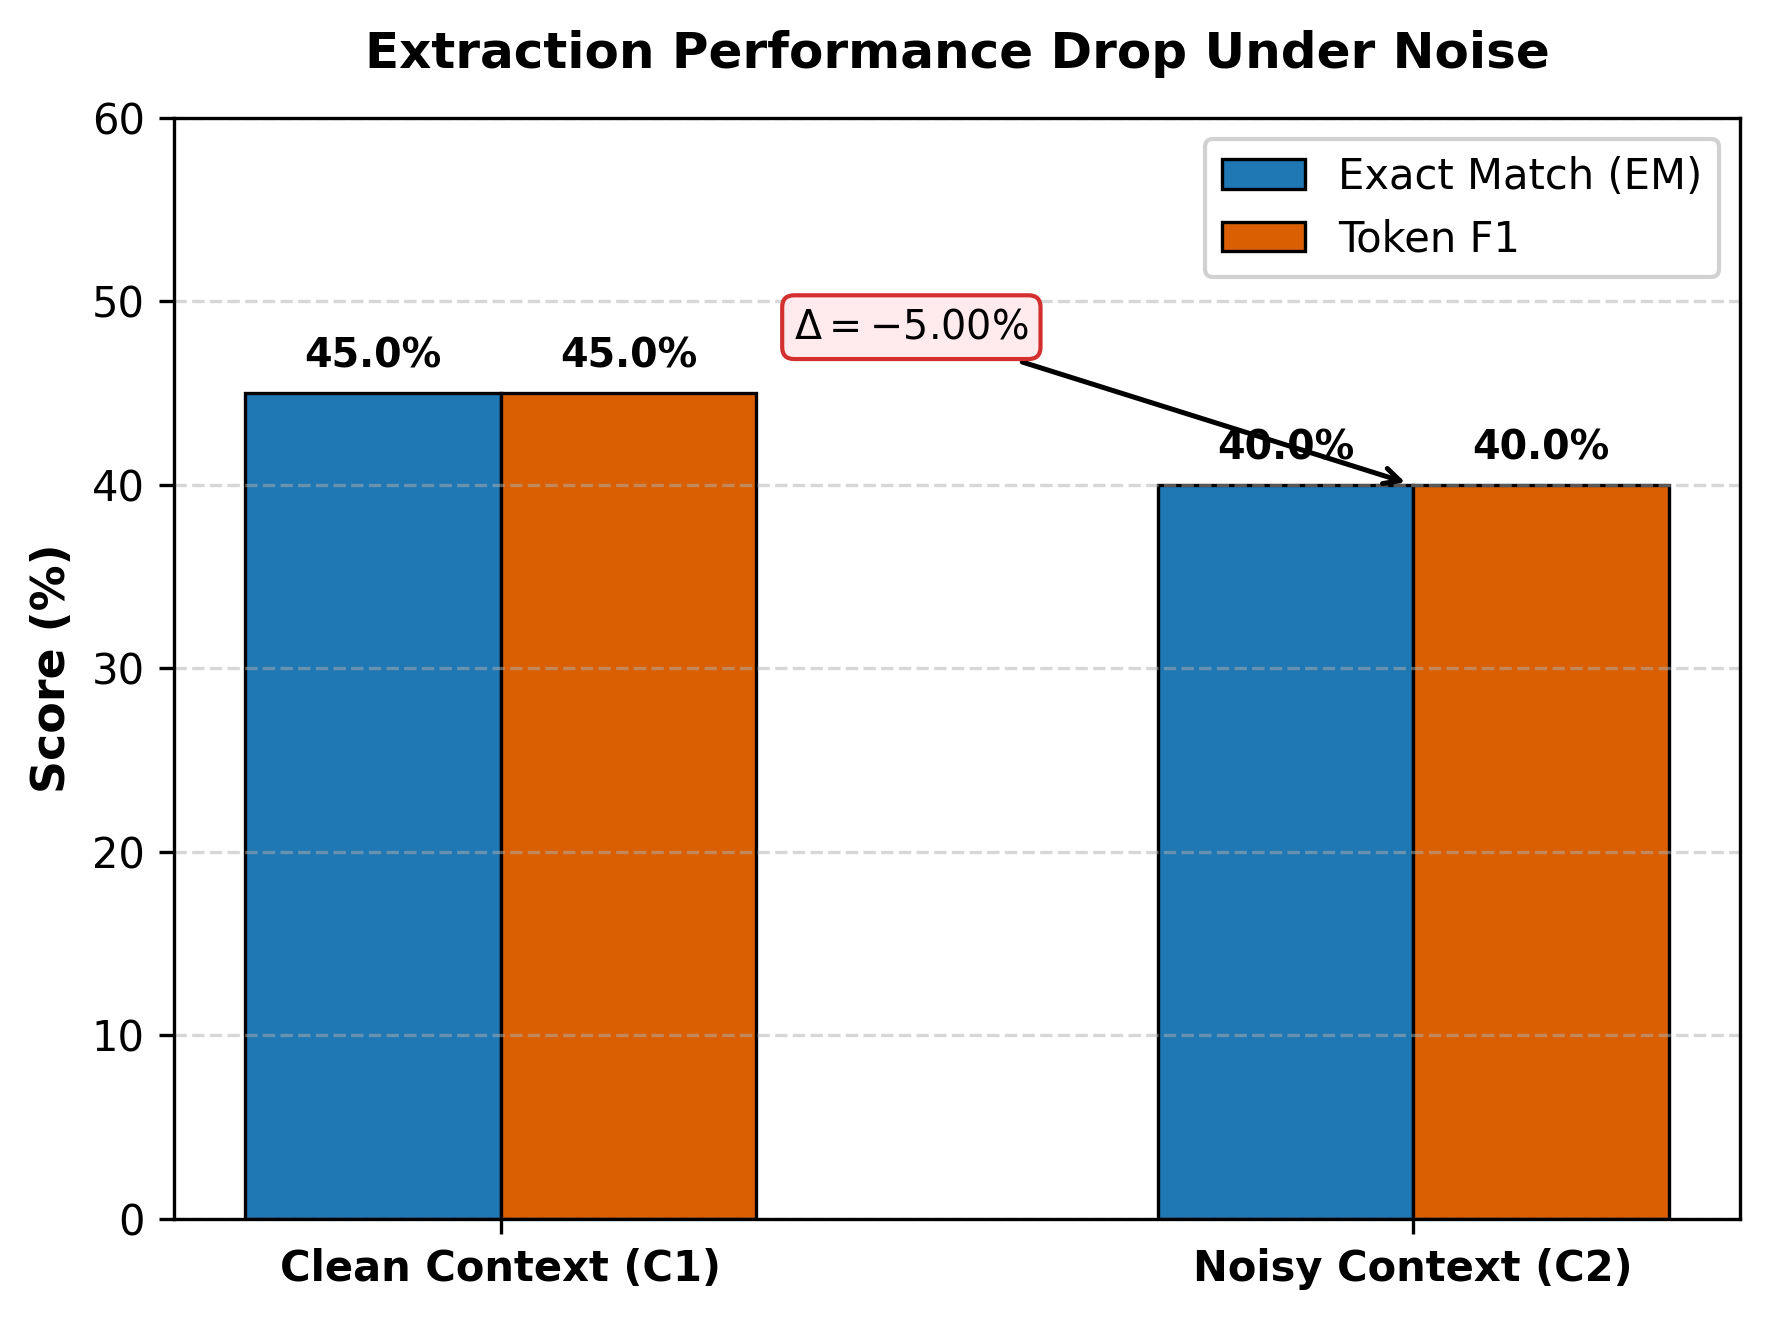

Figure 1 saved as 'poster_figure_1_performance.png'


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load empirical data
try:
  df = pd.read_csv("squad_rag_results.csv")
  em_c1 = df["em_clean"].mean() * 100
  em_c2 = df["em_noisy"].mean() * 100
  f1_c1 = df["f1_clean"].mean() * 100
  f1_c2 = df["f1_noisy"].mean() * 100
except Exception:
  em_c1, em_c2 = 45.0, 40.0
  f1_c1, f1_c2 = 45.0, 40.0

# Reset figure state completely
plt.close("all")
fig1, ax1 = plt.subplots(figsize=(6, 4.5), dpi=300)

labels = ["Clean Context (C1)", "Noisy Context (C2)"]
x = np.arange(len(labels))
width = 0.28

rects1 = ax1.bar(
    x - width / 2,
    [em_c1, em_c2],
    width,
    label="Exact Match (EM)",
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.8,
)
rects2 = ax1.bar(
    x + width / 2,
    [f1_c1, f1_c2],
    width,
    label="Token F1",
    color="#d95f02",
    edgecolor="black",
    linewidth=0.8,
)

ax1.set_ylabel("Score (%)", fontsize=11, fontweight="bold")
ax1.set_title(
    "Extraction Performance Drop Under Noise",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10, fontweight="semibold")
ax1.set_ylim(0, 60)
ax1.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for rect in rects1 + rects2:
  h = rect.get_height()
  ax1.annotate(
      f"{h:.1f}%",
      xy=(rect.get_x() + rect.get_width() / 2, h),
      xytext=(0, 4),
      textcoords="offset points",
      ha="center",
      va="bottom",
      fontsize=9.5,
      fontweight="bold",
  )

ax1.annotate(
    r"$\Delta = -5.00\%$",
    xy=(1, 40),
    xytext=(0.45, 48),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.2),
    fontsize=9.5,
    fontweight="bold",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="#ffebee", ec="#d32f2f", lw=1),
)

plt.tight_layout()
plt.savefig("poster_figure_1_performance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 1 saved as 'poster_figure_1_performance.png'")

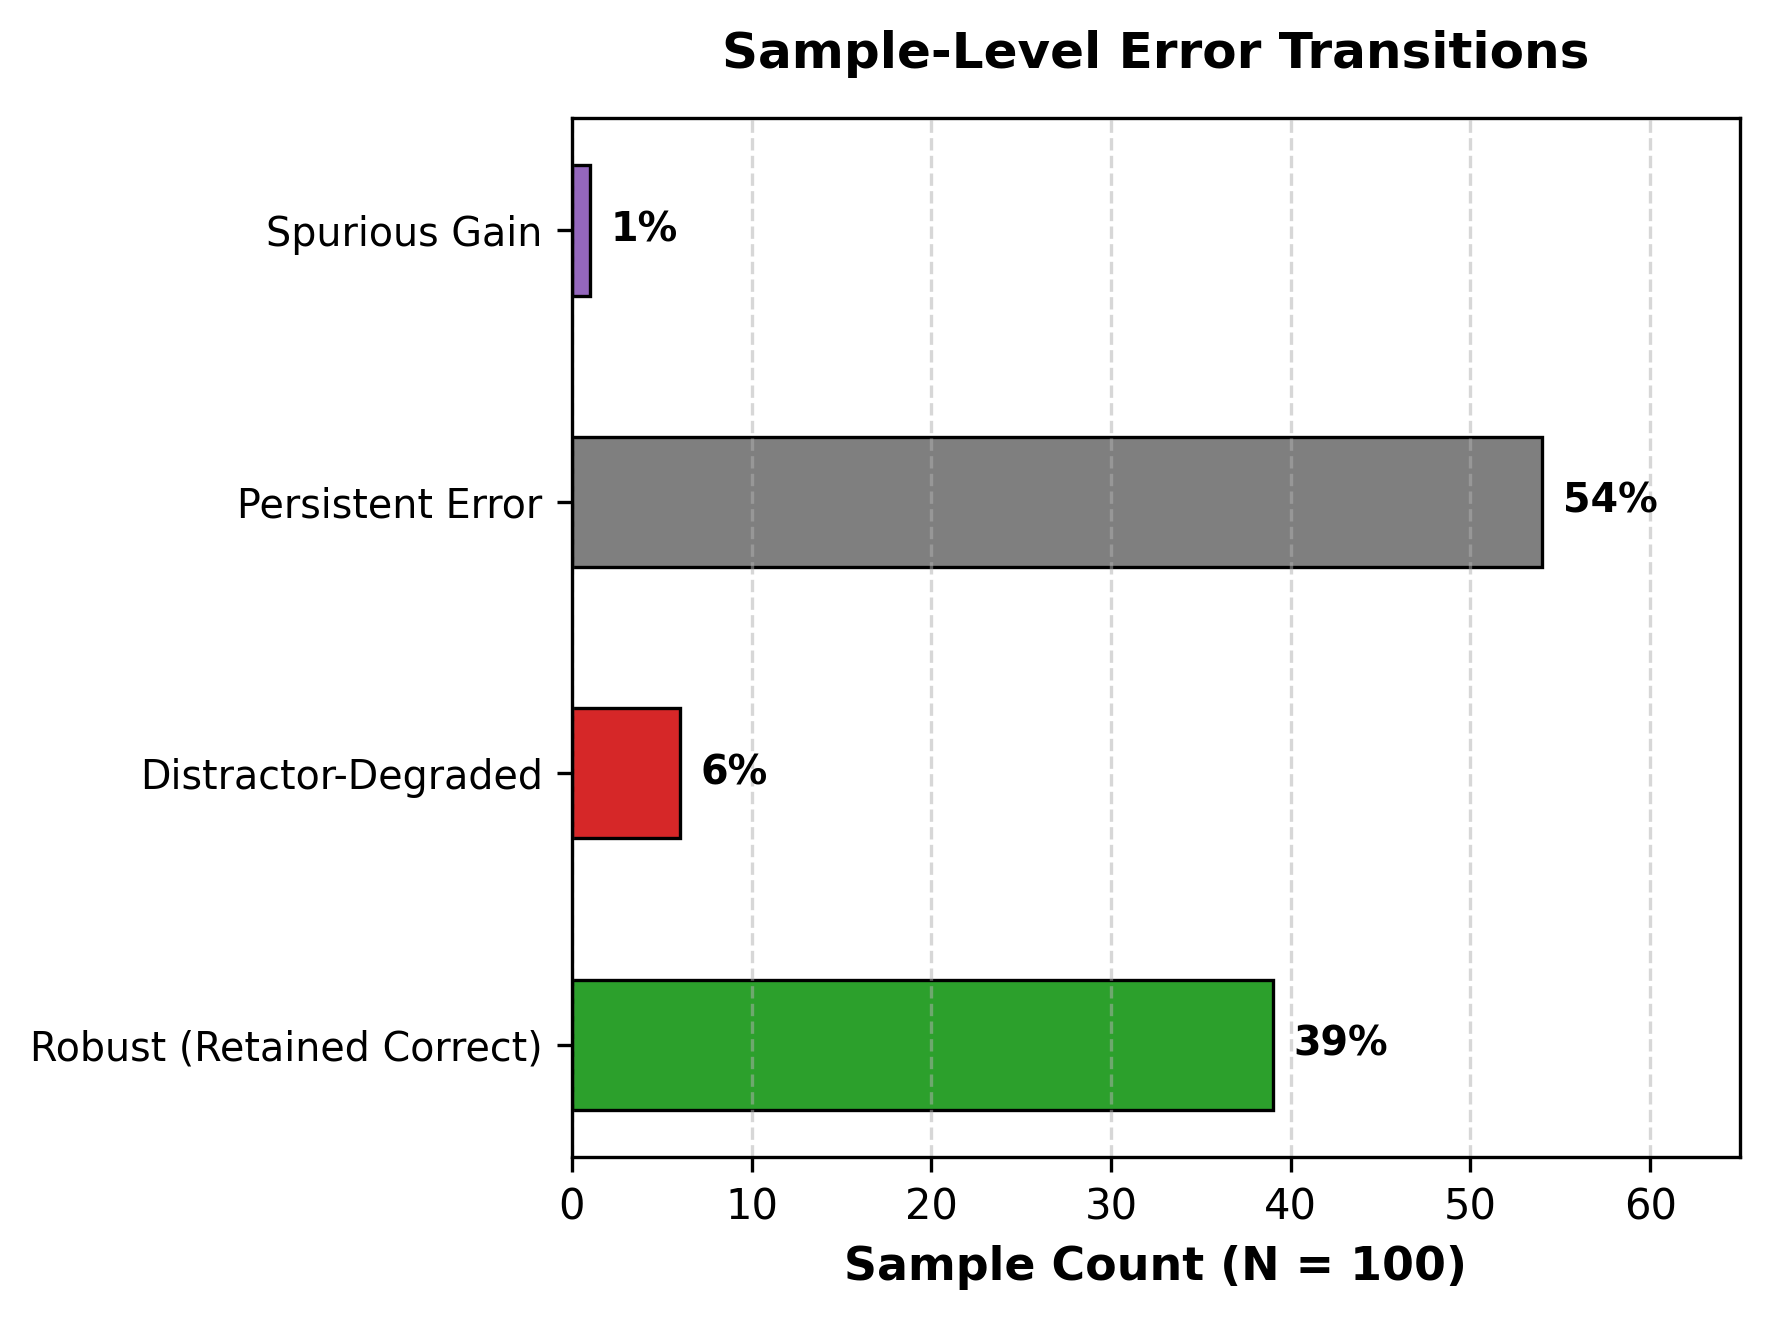

Figure 2 saved as 'poster_figure_2_transitions.png'


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

try:
  df = pd.read_csv("squad_rag_results.csv")
  robust = int(((df["em_clean"] == 1) & (df["em_noisy"] == 1)).sum())
  degraded = int(((df["em_clean"] == 1) & (df["em_noisy"] == 0)).sum())
  persistent_error = int(((df["em_clean"] == 0) & (df["em_noisy"] == 0)).sum())
  recovered = int(((df["em_clean"] == 0) & (df["em_noisy"] == 1)).sum())
except Exception:
  robust, degraded, persistent_error, recovered = 39, 6, 54, 1

plt.close("all")
fig2, ax2 = plt.subplots(figsize=(6, 4.5), dpi=300)

categories = [
    "Robust (Retained Correct)",
    "Distractor-Degraded",
    "Persistent Error",
    "Spurious Gain",
]
counts = [robust, degraded, persistent_error, recovered]
bar_colors = ["#2ca02c", "#d62728", "#7f7f7f", "#9467bd"]

bars = ax2.barh(
    categories,
    counts,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    height=0.48,
)
ax2.set_xlabel("Sample Count (N = 100)", fontsize=11, fontweight="bold")
ax2.set_title(
    "Sample-Level Error Transitions", fontsize=12, fontweight="bold", pad=12
)
ax2.set_xlim(0, 65)
ax2.grid(axis="x", linestyle="--", alpha=0.5)
ax2.tick_params(axis="y", labelsize=9.5)

for bar in bars:
  w = bar.get_width()
  ax2.annotate(
      f"{int(w)}%",
      xy=(w, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9.5,
      fontweight="bold",
  )

plt.tight_layout()
plt.savefig("poster_figure_2_transitions.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 2 saved as 'poster_figure_2_transitions.png'")